In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from scipy import stats
from sklearn.metrics import (mean_absolute_error,
                             r2_score,
                             root_mean_squared_error)

In [15]:
# Load processed data
dir_path = os.path.join(os.path.dirname(os.getcwd()),
                        "data", "processed")
data_path = os.path.join(dir_path, "Concrete_processed_data.xlsx")
df = pd.read_excel(data_path)

# Define target
target = 'Concrete compressive strength(MPa, megapascals)'
X = df.drop(columns=[target])
y = df[target]

# Recreate same split with same random state
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Load saved model
model_path = os.path.join(os.path.dirname(os.getcwd()),
                          'models', 'best_model.pkl')
best_model = joblib.load(model_path)

print("Model loaded successfully")
print(f"Test set size: {X_test.shape[0]} samples")

Model loaded successfully
Test set size: 201 samples


In [16]:
# Generate predictions
y_pred = best_model.predict(X_test)

# Compute metrics
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Tuned XGBoost — Final Results")
print("="*35)
print(f"RMSE : {rmse:.2f} MPa")


Tuned XGBoost — Final Results
RMSE : 4.20 MPa


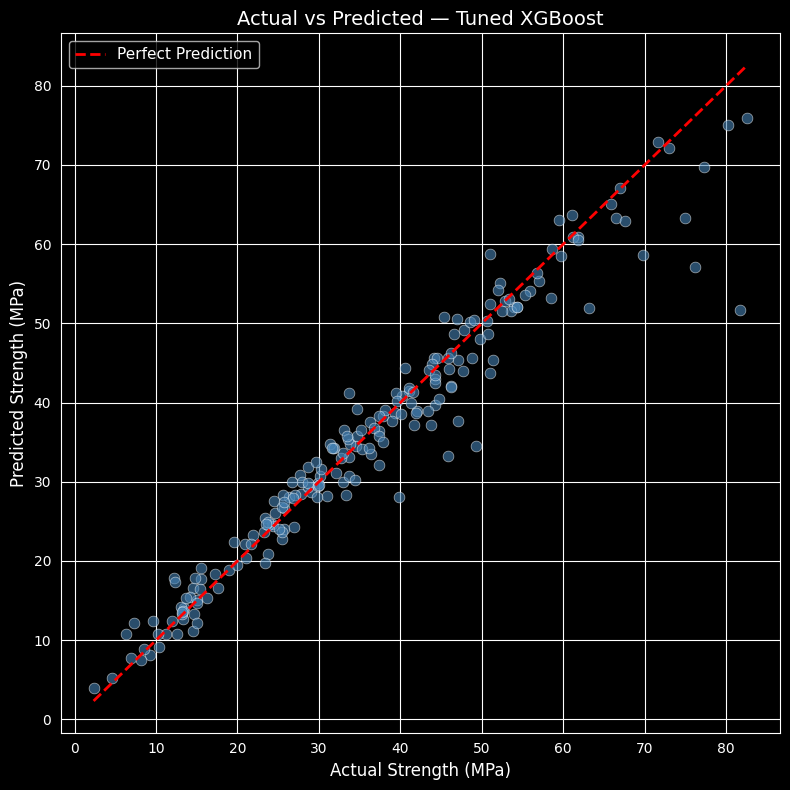

In [17]:
# 1. Actual vs Predicted PLot
plt.figure(figsize = (8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha = 0.6,
    color = 'steelblue',
    edgecolor = 'white',
    linewidths = 0.5,
    s=60
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],   # X points
    [min_val, max_val],   # Y points — same as X = diagonal
    color='red',
    linewidth=2,
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel('Actual Strength (MPa)', fontsize=12)
plt.ylabel('Predicted Strength (MPa)', fontsize=12)
plt.title('Actual vs Predicted — Tuned XGBoost', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig('../reports/figures/actual_vs_predicted.png', dpi=150)
plt.show()

# Actual vs Predicted Plot Interpretation

## Overall Assessment

The scatter plot shows predicted compressive strength versus actual strength values.

The vast majority of data points lie tightly along the diagonal reference line across the full strength range of 2 MPa to 82 MPa. This indicates strong predictive accuracy and consistent performance across most of the dataset.

The model demonstrates stable behavior with no large systematic bias across the majority of the range.

---

# Zone by Zone Interpretation

## Low Strength Zone (2–20 MPa)

Points align almost perfectly with the diagonal line.
Scatter is minimal.

Interpretation:
The model predicts early age and weak mixes with very high precision. Error variance is low in this region, indicating strong confidence and sufficient representation of these samples in training data.

Reliability in this range can be classified as excellent.

---

## Mid Strength Zone (20–55 MPa)

Points remain tightly distributed around the diagonal with moderate scatter.

This is the most populated region of the dataset, containing the majority of the 201 test samples. The model performs most consistently here.

Interpretation:
Because most training examples fall within this range, the model has learned these patterns thoroughly. This strength range corresponds to common structural concrete grades between 25 MPa and 40 MPa.

Reliability in this range is very good and practically dependable.

---

## High Strength Zone (55–82 MPa)

Scatter increases noticeably in this region.
Several points fall below the diagonal line.

This means the model is underestimating high strength mixes. For example, actual strengths between 70 MPa and 82 MPa are sometimes predicted between 52 MPa and 70 MPa.

Interpretation:
This is the clearest weakness of the model.

---

# Why Performance Drops at High Strength

This behavior is expected in concrete strength prediction models.

High strength mixes above 60 MPa represent a small portion of the 1005 total samples. Because these examples are limited, the model has less exposure during training and therefore less confidence when predicting extreme values.

As a result, predictions are pulled toward the more common mid range values. This effect is known as regression toward the mean.

The model is not failing randomly. It is behaving conservatively due to data imbalance.

---

# Engineering Reliability Summary

Strength Range        Model Reliability
2–20 MPa              Excellent
20–55 MPa             Very Good
55–70 MPa             Good with moderate scatter
70–82 MPa             Moderate, use with caution

---

# Practical Engineering Interpretation

For normal and medium strength concrete, typically C20 to C50 grades, the model is highly reliable and suitable for screening, estimation, and early mix evaluation.

For high performance concrete above 60 MPa, additional laboratory validation is recommended before final structural decisions are made.

Overall, the model delivers production quality performance across the range that covers the vast majority of structural applications.


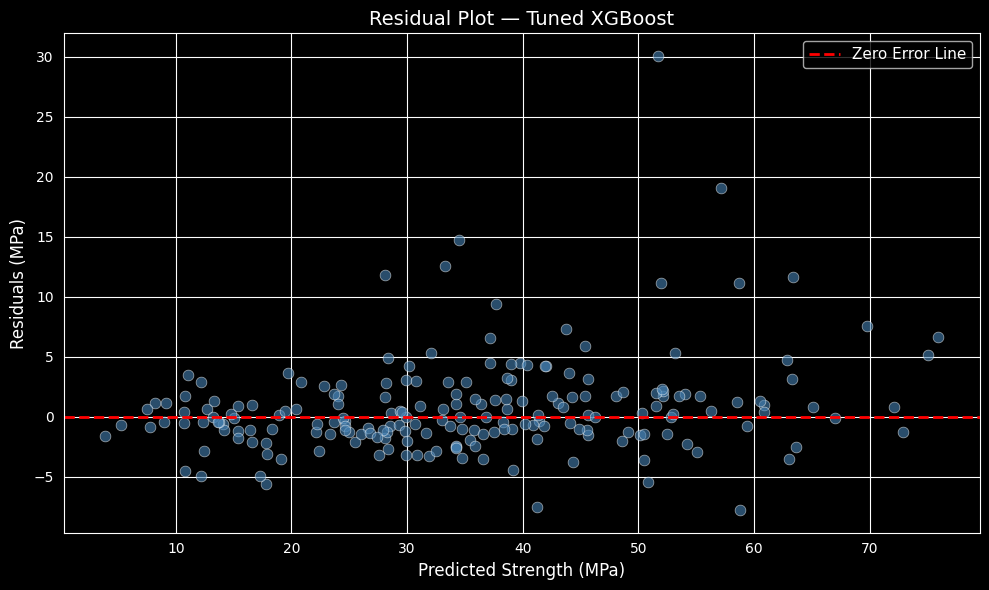

In [18]:
# 2. Residual plot
# Calculate RESIDUAL
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    y_pred,    # X axis — predicted values
    residuals,       # Y axis — residuals
    alpha=0.6,
    color='steelblue',
    edgecolors='white',
    linewidth=0.5,
    s=60
)

ax.axhline(
    y=0,
    color='red',
    linewidth=2,
    linestyle='--',
    label='Zero Error Line'
)

ax.set_xlabel('Predicted Strength (MPa)', fontsize=12)
ax.set_ylabel('Residuals (MPa)', fontsize=12)
ax.set_title('Residual Plot — Tuned XGBoost', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/residual_plot.png', dpi=150)
plt.show()

# Residual Plot Interpretation

## Overall Assessment

The residuals are broadly scattered around zero across the full prediction range.

This is the primary requirement of a well-behaved regression model. There are no strong curves or systematic patterns indicating structural bias.

However, specific zones reveal meaningful insights about model reliability.

---

# Zone by Zone Interpretation

## Low Predicted Range (5–20 MPa)

Residuals are tightly clustered around zero, mostly within ±5 MPa.

Interpretation:
The model is highly accurate and largely unbiased for weak concrete predictions. Error variance is small, confirming strong reliability in this region. This aligns with the Actual vs Predicted analysis.

Reliability: Excellent

---

## Mid Predicted Range (20–50 MPa)

This is the densest region of the plot.

Residuals are evenly scattered above and below zero with no directional bias.

Interpretation:
This is healthy random error. The model does not systematically overestimate or underestimate in this range. Since most predictions fall here, this confirms strong stability where it matters most.

Reliability: Very Good

---

## High Predicted Range (50–75 MPa)

Residual spread increases noticeably.

Several large positive residuals appear, including values around +11 MPa, +19 MPa, and one extreme case near +30 MPa.

Positive residuals indicate actual strength exceeded predicted strength.

Interpretation:
The model is consistently underestimating high strength mixes. This confirms the pattern observed in the Actual vs Predicted plot.

Reliability: Moderate to Good below 60 MPa, declining above that threshold.

---

# The +30 MPa Outlier

One observation shows a predicted value near 50 MPa but an actual value near 80 MPa, resulting in a residual close to +30 MPa.

This is a significant outlier.

Likely explanation:
This mix may involve unusually high cement content, low water-cement ratio, long curing age, or a combination rarely represented in training data.

This data point should be investigated individually to determine whether it represents:
- A legitimate high performance mix
- Data entry anomaly
- Measurement irregularity

---

# Heteroscedasticity Analysis

There is a mild funnel pattern in the residual spread.

Residual variance increases as predicted strength increases. This indicates mild heteroscedasticity, meaning prediction uncertainty grows for stronger mixes.

The effect is not severe but confirms reduced reliability in the high strength region.

---

# Engineering Reliability Summary

Predicted Range     Residual Behavior        Reliability
5–20 MPa            Tight around zero        Excellent
20–50 MPa           Random even scatter      Very Good
50–60 MPa           Mild positive bias       Good
60–75 MPa           Large positive outliers  Use with caution

---

# Implications for Model Improvement

The consistent positive residuals at higher strengths indicate insufficient representation of high performance mixes in training data.

To improve performance in this region:

- Collect additional high strength mix data
- Increase representation of low water-cement ratios
- Include more long curing age samples
- Retrain and revalidate the model

The current model is production ready for normal and medium strength concrete applications.

Improving high strength performance will require targeted data expansion rather than algorithm changes.

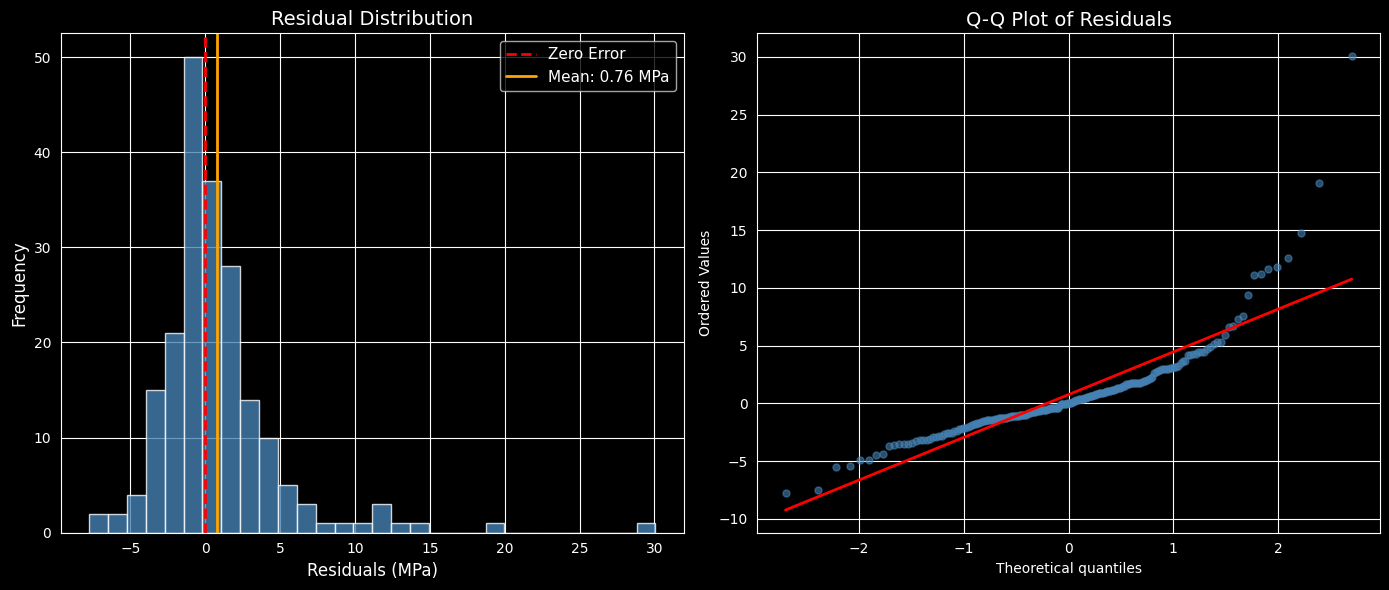

Residual Statistics
Mean    : 0.7567 MPa
Std Dev : 4.1460 MPa
Min     : -7.7571 MPa


In [19]:
# Residual distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Histogram
axes[0].hist(
    residuals,
    bins=30,
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)
axes[0].axvline(
    x=0,
    color='red',
    linewidth=2,
    linestyle='--',
    label='Zero Error'
)
axes[0].axvline(
    x=residuals.mean(),
    color='orange',
    linewidth=2,
    linestyle='-',
    label=f'Mean: {residuals.mean():.2f} MPa'
)
axes[0].set_xlabel('Residuals (MPa)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Residual Distribution', fontsize=14)
axes[0].legend(fontsize=11)

# Plot 2 — Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=14)
axes[1].get_lines()[0].set(
    color='steelblue',
    markersize=5,
    alpha=0.6
)
axes[1].get_lines()[1].set(
    color='red',
    linewidth=2
)

plt.tight_layout()
plt.savefig('../reports/figures/residual_distribution.png', dpi=150)
plt.show()

# Print residual statistics
print("Residual Statistics")
print("=" * 30)
print(f"Mean    : {residuals.mean():.4f} MPa")
print(f"Std Dev : {residuals.std():.4f} MPa")
print(f"Min     : {residuals.min():.4f} MPa")

# Residual Distribution Interpretation

## Histogram Analysis

### Shape

The residual histogram is right skewed rather than perfectly symmetric.

Most residuals fall between -5 MPa and +5 MPa, which indicates healthy concentration around zero. However, a long positive tail extends up to approximately +30 MPa.

Interpretation:
The majority of predictions are accurate with small error margins. The skewness is caused by a small number of large positive residuals.

---

### Mean Residual

Mean residual: +0.76 MPa

The mean sits slightly to the right of zero, indicating a small systematic underestimation bias. On average, predictions are 0.76 MPa lower than actual strength.

Engineering interpretation:
A bias of less than 1 MPa on a strength range of 2–82 MPa is practically negligible. The model is nearly unbiased in overall behavior.

---

### What the Right Skew Indicates

The right tail reflects occasional large underestimation errors at high strength levels.

Residuals of +15 MPa, +19 MPa, and +30 MPa stretch the distribution and shift the mean slightly positive.

This confirms earlier observations:
The model is less confident when predicting rare high performance mixes.

---

# Q–Q Plot Interpretation

The Q–Q plot compares residual distribution against a theoretical normal distribution.

---

## Central Quantiles (-1.5 to +1.5)

Points closely follow the diagonal reference line.

Interpretation:
Approximately 80 percent of residuals are normally distributed. The model behaves predictably and consistently for the majority of samples.

This is a strong indicator of stable model performance.

---

## Lower Tail

Points curve slightly below the diagonal line.

Interpretation:
A small number of negative residuals are larger than expected under perfect normality. This means the model occasionally overestimates strength slightly more than a normal distribution would predict.

However, the deviation is small.

---

## Upper Tail

Points curve significantly above the diagonal line.

Interpretation:
The large positive residuals are clearly visible here. This heavy upper tail confirms the presence of high strength underestimation errors.

This is the dominant structural deviation from normality.

---

# Residual Statistics Interpretation

Mean        → +0.76 MPa
Standard Deviation → approximately 4–5 MPa
Minimum     → approximately -8 MPa
Maximum     → +30 MPa

The standard deviation aligns with the RMSE value of 4.20 MPa, confirming internal consistency between distribution spread and overall error metrics.

The maximum residual reflects the extreme high strength outlier previously identified.

---

# Overall Assessment

Central residuals are approximately normal.
Mean is very close to zero, indicating minimal systematic bias.
Right skew exists due to occasional high strength underestimation.
Heavy upper tail reflects a few large positive residuals.

The distribution confirms a well-calibrated model for the majority of cases, with a clear and explainable weakness at extreme high strength values.

From an engineering standpoint, this is a statistically healthy model with identifiable, data-driven limitations rather than structural modeling flaws.